### 6. 학습 관련 기술들
---

### 6-1. 매개변수 갱신
###### 가중치와 bias 같은 매개변수의 최적값을 찾는 것을 최적화라고 한다. 매개변수의 기울기를 구해 매개변수 값을 갱신하는 방법을 확률적 경사 하강법(SGD)라고 한다.


In [1]:
# SGD를 이용한 업데이트 방법

class SGD:
    def __init__(self, lr = 0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

- 이처럼 최적화를 담당하는 클래스를 분리해 구현하면 기능을 모듈화하기 좋다.

- *SGD 단점: 기울어진 방향이 최솟값과 다른 방향을 가리키면 지그재그로 탐색해서 비효율적이다.
---

#### 모멘텀

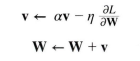

##### 모멘텀 업데이트 식에는 기존 경사하강법과 다르게 v가 추가되는데 이는 update 전의 방향과 이동량을 어느정도 유지시킨 상태에서 losff function의 기울기를 이용하여 v를 업데이트 한다는 의미이다.
- av 항은 물체가 아무런 힘을 받지 않을 때 서서히 하강시키는 역할을 한다. a는 보통 0.9로 설정한다.

In [ ]:
# Momentum

class Momentum:
    def __init__(self, lr = 0.01, momentum = 0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val) # v가 비어있으면 params에 있는 key,value를 복제한다 (value는 0으로)

        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr * grads[key]
            params[key] += self.v[key]


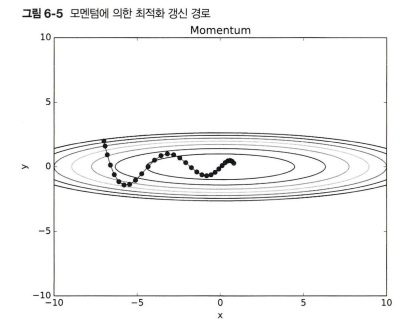
- SGD를 사용했을 때와 다르게 지그재그가 없는 것을 볼 수 있다.(av항이 속도를 유지시켜주기 때문에)

---

#### AdaGrad
###### 신경망 학습에서는 학습률 값이 중요하다. 이 학습률을 정하는 효과적 기술로 학습률 감소가 있다.

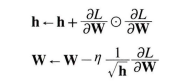

- 식을 보면 h가 분모로 들어가면서 학습률이 점점 감소하는 것을 확인할 수 있다.


In [ ]:
import numpy as np


class Adagrad:
    def __init__(self, lr = 0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
        
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7) # 1e-7을 더함으로써 self.h[key]에 0이 담겨 있다 해도 0으로 나누는 사태를 막아준다.



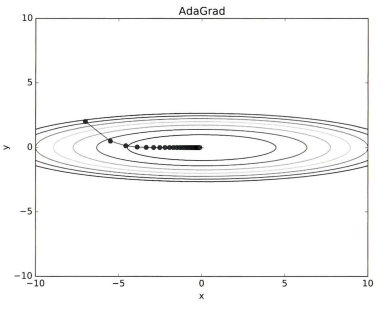

- 큰 움직임에 비례해 갱신 정도도 큰 폭으로 작아지도록 조정된다.
- 지금까지 알아본 갱신 방법들 중 어느 문제를 풀 지에 따라 방법을 선택하면 된다.
---

### 6-2. 가중치의 초깃값


1. ***초깃값을 0***
- 오차역전파법에서 모든 가중치의 값이 똑같이 갱신되기 때문에 안 좋은 생각.
----


2. 은닉층의 활성화값 분포

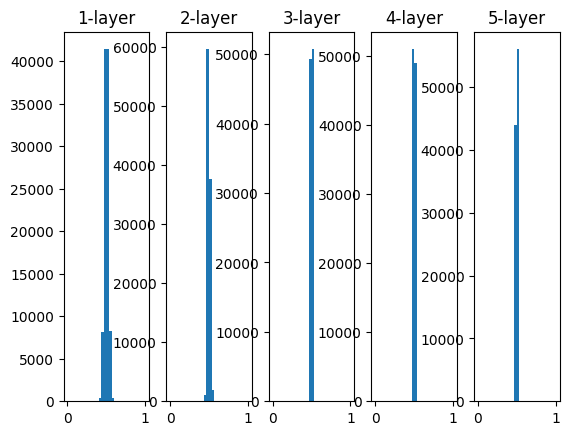

In [12]:
# 분포된 정도를 바꿔가며 활성화값들의 분포가 어떻게 변화하는지 관찰하는 것이 이 실험의 목적이다.

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.random.randn(1000, 100)
node_num = 100
hidden_layer_size = 5
activations = {}

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = np.random.randn(node_num, node_num) * 0.01 # 표준편차를 바꿔가며 활성화값들의 분포가 어떻게 변화하는지 관찰

    a = np.dot(x,w)
    z = sigmoid(a)
    activations[i] = z        


for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    plt.hist(a.flatten(), 30, range = (0,1))

plt.show()

- 표준편차가 1일 때는 0,1에 치우쳐져 있어서 기울기 소실 문제가 일어나고, 표준편차가 0.01일 때는 0,1에 치우치진 않았으나 활성화값들이 가운데 치우쳐져 있어서 데이터가 100개나 1개나 똑같은 효과를 낸다. 

#### *Xavier 초깃값
###### 딥러닝 프레임워크들이 표준적으로 이용하고 있다.
- 앞 계층의 노드가 n개라면 표준편차가 1/np.sqrt(n)


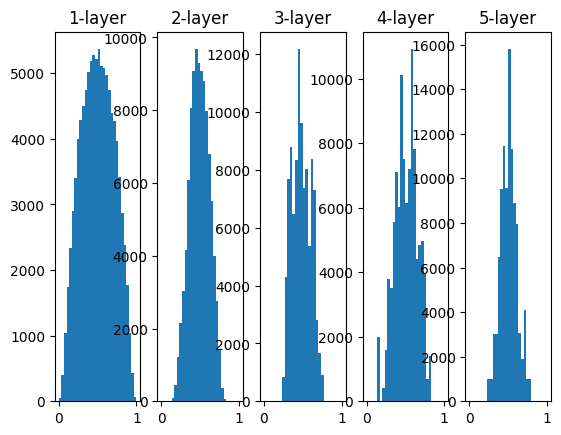

In [13]:
# Xavier 초깃값 적용

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.random.randn(1000, 100)
node_num = 100
hidden_layer_size = 5
activations = {}

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = np.random.randn(node_num, node_num) / np.sqrt(node_num)

    a = np.dot(x,w)
    z = sigmoid(a)
    activations[i] = z        


for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    plt.hist(a.flatten(), 30, range = (0,1))

plt.show()

----

3. ReLU를 사용할 때의 가중치 초깃값
###### 보통 Xavier 초깃값을 사용하지만 ReLU 함수를 사용할 때는 He 초깃값을 사용한다.
- 앞 계층의 노드가 n개일 때 표준편차가 np.sqry(2/n)

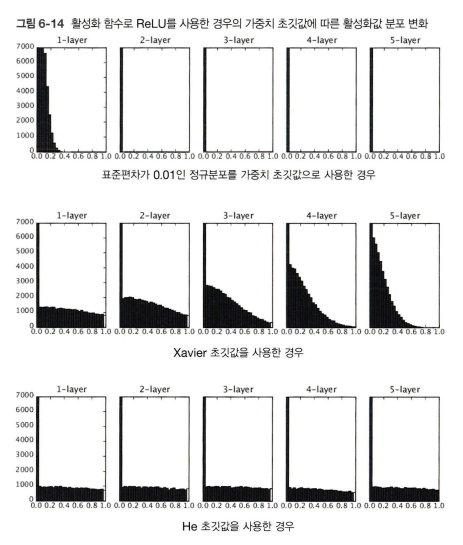


- std = 0.01인 경우는 기울기가 너무 작아서 학습이 거의 안 이뤄지고 Xavier 초깃값은 층이 깊어지면서 기울기 소실 문제가 발생한다.
- He 초깃값을 사용했을 때 가장 분포가 좋다.
- 결론: ReLU를 사용할 때는 He 초깃값을, 다른 곡선일 때는 Xavier 초깃값을 사용.